<a href="https://colab.research.google.com/github/khushi-narang/ml/blob/main/titanic_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Titanic-Dataset.csv").copy()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
for column in df.columns:
  if df[column].isnull().any():
    most_frequent_value = df[column].mode()[0]  # Get the most frequent value
    df[column].fillna(most_frequent_value, inplace=True)

<ipython-input-4-d635def283e6>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(most_frequent_value, inplace=True)


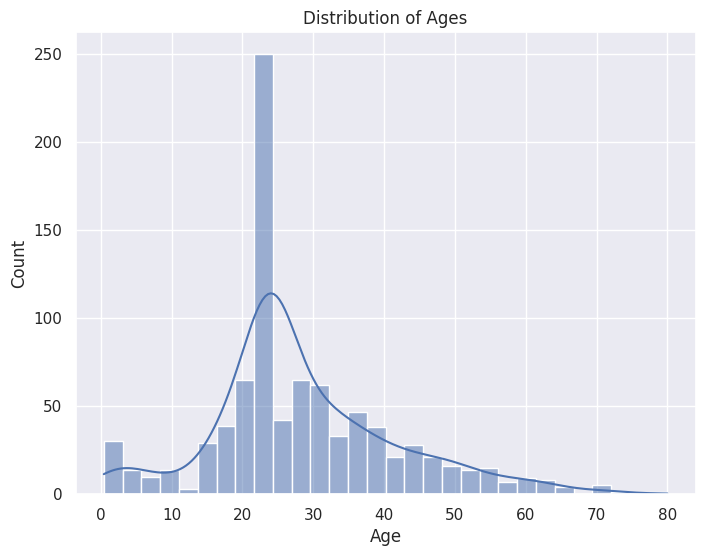

In [ ]:
sns.set()
plt.figure(figsize=(8, 6))
sns.histplot(df['Age'], kde=True)
plt.title('Distribution of Ages')
plt.show()

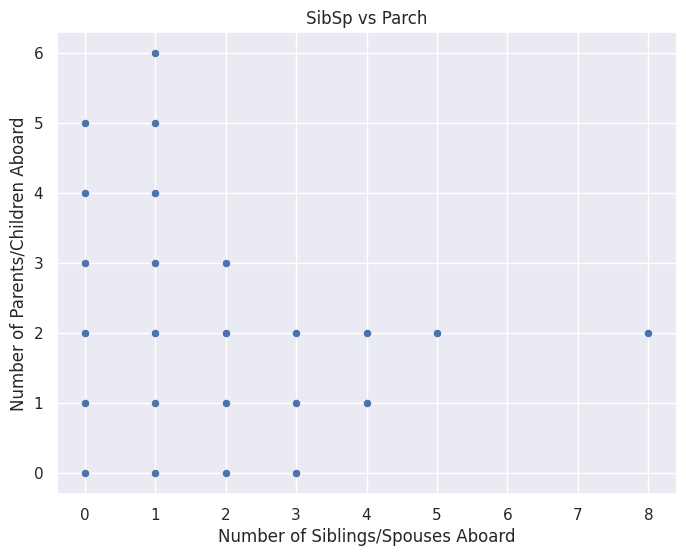

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='SibSp', y='Parch', data=df)
plt.title('SibSp vs Parch')
plt.xlabel('Number of Siblings/Spouses Aboard')
plt.ylabel('Number of Parents/Children Aboard')
plt.show()

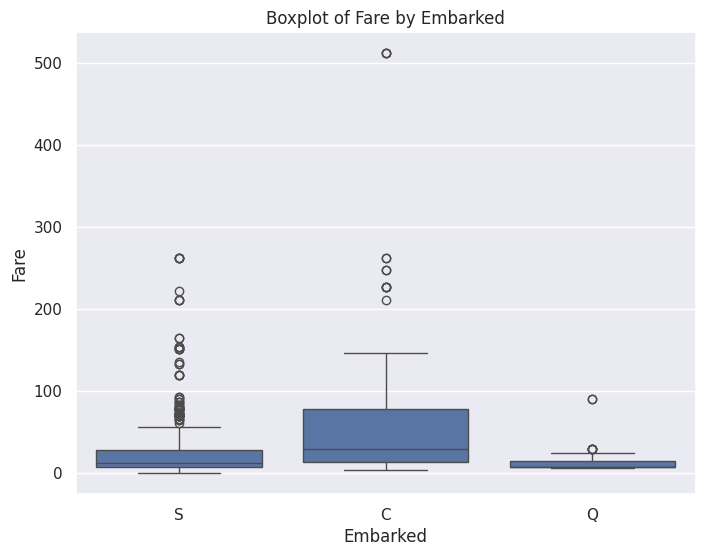

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Embarked', y='Fare', data=df)
plt.title('Boxplot of Fare by Embarked')
plt.show()

<Figure size 800x600 with 0 Axes>

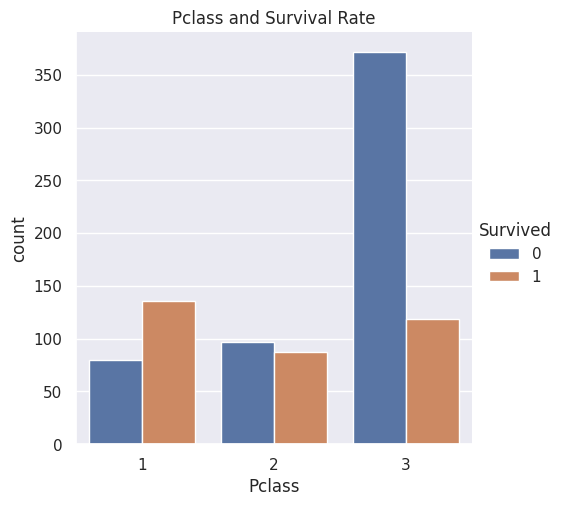

<Figure size 800x600 with 0 Axes>

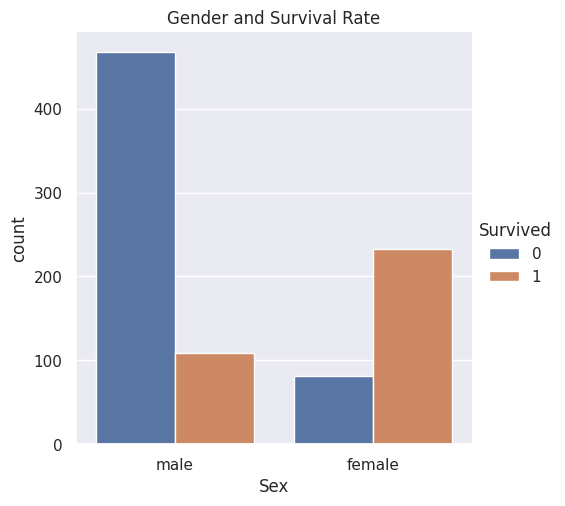

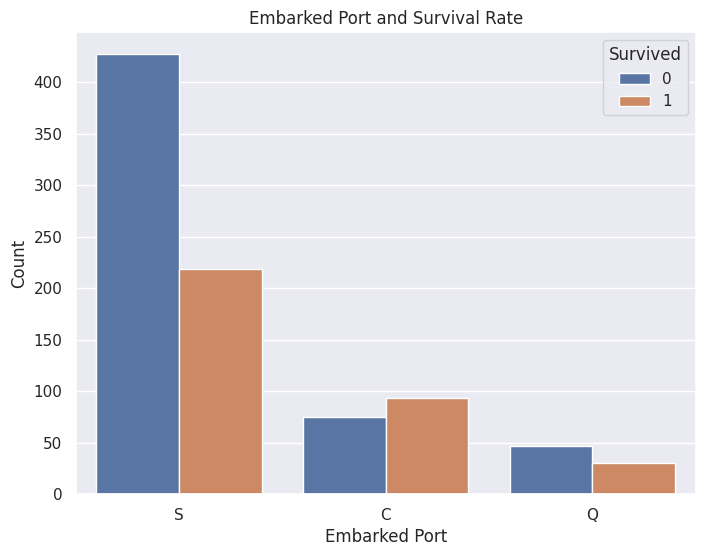

In [ ]:
# Pclass and Survival Rate
plt.figure(figsize=(8, 6))
sns.catplot(x='Pclass', hue='Survived', kind='count', data=df)
plt.title('Pclass and Survival Rate')
plt.show()

# Gender and Survival Rate
plt.figure(figsize=(8, 6))
sns.catplot(x='Sex', hue='Survived', kind='count', data=df)
plt.title('Gender and Survival Rate')
plt.show()

# Embarked Port and Survival Rate
plt.figure(figsize=(8, 6))
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.xlabel('Embarked Port')
plt.ylabel('Count')
plt.title('Embarked Port and Survival Rate')
plt.show()

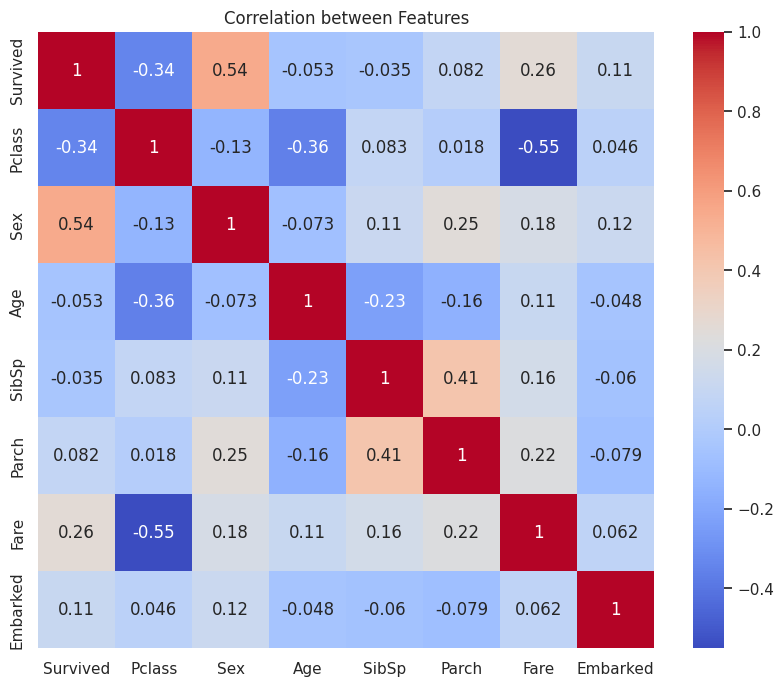

In [ ]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

x = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
corr = x.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', square=True)
plt.title('Correlation between Features')
plt.show()

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Prepare the data
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df['Survived'][X.index]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=702)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the kernels to use
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

for kernel in kernels:
  # Train the SVM model
  svm_model = SVC(kernel=kernel)
  svm_model.fit(X_train, y_train)

  # Make predictions
  y_pred = svm_model.predict(X_test)

  # Evaluate the model
  accuracy = accuracy_score(y_test, y_pred)
  print(f"{kernel} Kernel : {accuracy}")

linear Kernel : 0.7877094972067039
poly Kernel : 0.8379888268156425
rbf Kernel : 0.8379888268156425
sigmoid Kernel : 0.7039106145251397


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC

# ... (Your existing code for loading data, splitting, scaling, etc.) ...

# Iterate through different SVM kernels and analyze performance
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

for kernel in kernels:
    svm_classifier = SVC(kernel=kernel, random_state=702)

    # Fix: Convert y_train to a 1D array using .values.ravel()
    svm_classifier.fit(X_train, y_train.values.ravel())

    y_pred_svm = svm_classifier.predict(X_test)

    accuracy_svm = accuracy_score(y_test, y_pred_svm)
    print(f"\nSVM with {kernel} kernel:")
    print(f"Accuracy: {accuracy_svm}")

    # Generate and print the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred_svm))

    # Generate and print the confusion matrix
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_svm))


SVM with linear kernel:
Accuracy: 0.7877094972067039
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       113
           1       0.75      0.64      0.69        66

    accuracy                           0.79       179
   macro avg       0.78      0.76      0.76       179
weighted avg       0.78      0.79      0.78       179

Confusion Matrix:
[[99 14]
 [24 42]]

SVM with poly kernel:
Accuracy: 0.8379888268156425
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.96      0.88       113
           1       0.89      0.64      0.74        66

    accuracy                           0.84       179
   macro avg       0.86      0.80      0.81       179
weighted avg       0.85      0.84      0.83       179

Confusion Matrix:
[[108   5]
 [ 24  42]]

SVM with rbf kernel:
Accuracy: 0.8379888268156425
Classification Report:
              precision    recall  f1-scor